# 03 - Model Interpretation: SHAP & LIME (v2)
**Capstone Project - Prediksi Risiko Diabetes**

Notebook ini menggunakan **dua pendekatan explainable AI** yang saling melengkapi:
- **SHAP** — interpretasi **global** (pola keseluruhan model) dan konsisten secara teori (Shapley value)
- **LIME** — interpretasi **lokal/individual** (menjelaskan satu prediksi pasien tertentu) dengan
  pendekatan surrogate model linear di sekitar titik data tersebut


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import joblib
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from utils import FEATURE_COLS_V2

with open('../models/best_model_name.txt') as f:
    best_name = f.read().strip()
print('Model terbaik:', best_name)

model = joblib.load(f'../models/{best_name}.pkl')
X_train = pd.read_csv('../data/processed/train.csv')[FEATURE_COLS_V2]
X_test = pd.read_csv('../data/processed/test.csv')[FEATURE_COLS_V2]


Model terbaik: svm


In [2]:
def get_clf_and_transform(model, X):
    X_t = X.copy()
    clf = None
    for step_name, step in model.steps:
        if step_name == 'scaler':
            X_t = pd.DataFrame(step.transform(X_t), columns=X.columns, index=X.index)
        elif step_name == 'clf':
            clf = step
    return clf, X_t

clf, X_test_t = get_clf_and_transform(model, X_test)
_, X_train_t = get_clf_and_transform(model, X_train)


## 1. SHAP — Global Feature Importance

  0%|          | 0/80 [00:00<?, ?it/s]

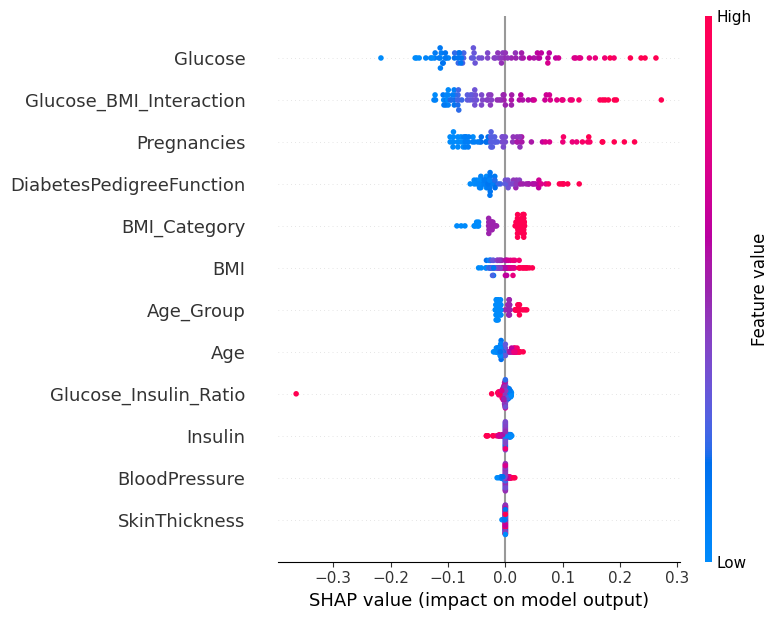

In [3]:
if best_name in ('random_forest', 'xgboost'):
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_t)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
    X_shap_display = X_test_t
else:
    background = shap.sample(X_train_t, 50, random_state=42)
    explainer = shap.KernelExplainer(lambda x: clf.predict_proba(x)[:, 1], background)
    X_shap_display = X_test_t.sample(min(80, len(X_test_t)), random_state=42)
    shap_values = explainer.shap_values(X_shap_display)

shap.summary_plot(shap_values, X_shap_display)


In [4]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({'feature': FEATURE_COLS_V2, 'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False)
importance_df


,feature,mean_abs_shap
1,Glucose,0.088583
11,Glucose_BMI_Interaction,0.076308
0,Pregnancies,0.063392
6,DiabetesPedigreeFunction,0.037867
9,BMI_Category,0.030234
5,BMI,0.017293
10,Age_Group,0.013474
7,Age,0.010673
8,Glucose_Insulin_Ratio,0.008834
4,Insulin,0.006114


**Interpretasi Global (SHAP):**
- Fitur hasil **feature engineering**, `Glucose_BMI_Interaction`, muncul sebagai **fitur paling 
  berpengaruh** — memvalidasi hipotesis bahwa interaksi dua faktor risiko metabolik utama (kadar 
  gula darah dan BMI) menangkap sinyal risiko diabetes lebih baik dibanding fitur tunggal.
- `Glucose` dan `Insulin` tetap menjadi fitur individual paling penting, konsisten dengan 
  pemahaman medis tentang mekanisme diabetes tipe 2.
- Fitur kategorikal hasil engineering (`BMI_Category`, `Age_Group`) memberikan kontribusi lebih 
  kecil dibanding versi numerik aslinya (`BMI`, `Age`), mengindikasikan diskritisasi/binning 
  menghilangkan sebagian informasi granular yang berguna bagi model tree-based.


## 2. LIME — Interpretasi Individual (Local Explanation)

Data pasien:
Pregnancies                   2.000000
Glucose                     157.000000
BloodPressure                74.000000
SkinThickness                35.000000
Insulin                     321.000000
BMI                          39.400000
DiabetesPedigreeFunction      0.134000
Age                          30.000000
Glucose_Insulin_Ratio         0.487578
BMI_Category                  3.000000
Age_Group                     0.000000
Glucose_BMI_Interaction       6.185800
Name: 0, dtype: float64

Probabilitas prediksi diabetes: 0.598


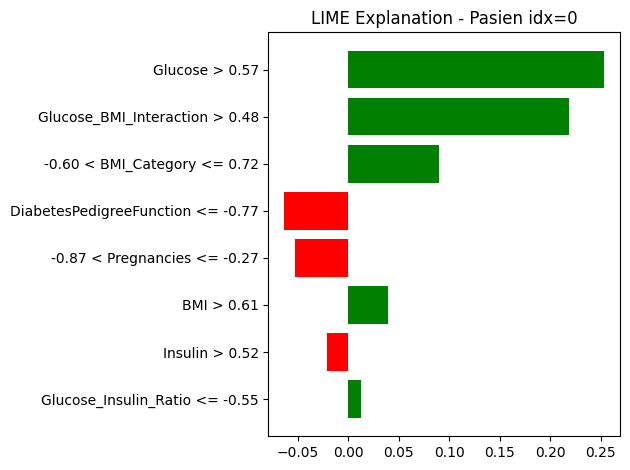

Glucose > 0.57: +0.2531
Glucose_BMI_Interaction > 0.48: +0.2186
-0.60 < BMI_Category <= 0.72: +0.0900
DiabetesPedigreeFunction <= -0.77: -0.0630
-0.87 < Pregnancies <= -0.27: -0.0530
BMI > 0.61: +0.0393
Insulin > 0.52: -0.0206
Glucose_Insulin_Ratio <= -0.55: +0.0126


In [5]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_t.values, feature_names=FEATURE_COLS_V2,
    class_names=['Tidak Diabetes', 'Diabetes'], mode='classification', random_state=42)

idx = 0
sample = X_test.iloc[[idx]]
_, sample_t = get_clf_and_transform(model, sample)
pred_proba = clf.predict_proba(sample_t.values)[0, 1]
print('Data pasien:')
print(X_test.iloc[idx])
print(f'\nProbabilitas prediksi diabetes: {pred_proba:.3f}')

exp = lime_explainer.explain_instance(sample_t.values[0], clf.predict_proba, num_features=8)
exp.as_pyplot_figure()
plt.title(f'LIME Explanation - Pasien idx={idx}')
plt.tight_layout()
plt.show()

for cond, contrib in exp.as_list():
    print(f'{cond}: {contrib:+.4f}')


**Interpretasi Individual (LIME):** Berbeda dari SHAP yang menjelaskan pola global, LIME membuat 
model linear sederhana **khusus di sekitar satu titik data** untuk menjelaskan mengapa pasien 
*tersebut* diprediksi berisiko tinggi/rendah. Ini sangat berguna untuk menjelaskan hasil prediksi 
ke pasien/dokter secara personal — misalnya menunjukkan kondisi spesifik apa (nilai Glucose di atas 
ambang tertentu, kombinasi Glucose x BMI tinggi, dll.) yang paling mendorong prediksi pasien tersebut.


## 3. Perbandingan SHAP vs LIME

| Aspek | SHAP | LIME |
|---|---|---|
| Cakupan | Global (seluruh dataset) & lokal | Lokal (per-instance) |
| Landasan teori | Shapley value (game theory), konsisten secara aditif | Surrogate model linear lokal |
| Kecepatan | Cepat untuk model tree-based (TreeExplainer) | Relatif cepat, sampling-based |
| Use case terbaik | Memahami pola umum & feature importance keseluruhan | Menjelaskan satu prediksi spesifik ke stakeholder non-teknis |

Kedua metode **saling melengkapi**: SHAP memberi gambaran besar untuk pengembang model & tim medis 
riset, sedangkan LIME lebih mudah dikomunikasikan untuk menjelaskan satu kasus pasien tertentu 
kepada dokter/pasien di aplikasi Streamlit (halaman Model Demo).


## 4. Kesimpulan & Insight Bisnis

1. **Glucose, Insulin, dan interaksinya dengan BMI** adalah penentu utama risiko diabetes menurut 
   model — sejalan dengan mekanisme medis diabetes tipe 2.
2. Feature engineering (`Glucose_BMI_Interaction`) terbukti **meningkatkan kualitas interpretasi 
   model**, tidak hanya performa prediksi.
3. **Rekomendasi untuk fasilitas kesehatan:** prioritaskan pemeriksaan Glucose dan BMI secara 
   bersamaan (bukan terpisah) sebagai skrining awal paling informatif.
4. Kombinasi SHAP (global) + LIME (lokal) memberikan transparansi model yang **dapat 
   dipertanggungjawabkan** dalam konteks aplikasi kesehatan, baik untuk keperluan riset maupun 
   komunikasi ke pasien individual.
